# UAS Mata Kuliah Machine Learning
## Judul: Prediksi Konsentrasi Karbon Monoksida (CO) Menggunakan Random Forest pada Data Kualitas Udara


**Dosen Pengampu:** Hardiansyah

**Identitas Mahasiswa:**
- **Nama:**  Mohammad Hadi Purnomo (231011402465)
- **Kelas:** 05TPLP001

---

### 1. Problem Definition
**Latar Belakang:**
Kualitas udara merupakan salah satu faktor penting yang berpengaruh terhadap kesehatan manusia dan lingkungan. Peningkatan aktivitas industri dan transportasi menyebabkan meningkatnya konsentrasi gas polutan seperti karbon monoksida (CO), nitrogen dioksida (NO₂), dan senyawa organik volatil di udara. Oleh karena itu, pemantauan dan prediksi kualitas udara menjadi penting sebagai langkah mitigasi terhadap dampak negatif pencemaran udara.

Dengan berkembangnya teknik machine learning, analisis data sensor kualitas udara dapat digunakan untuk memprediksi konsentrasi polutan secara lebih akurat. Pemanfaatan data historis kualitas udara memungkinkan identifikasi pola dan hubungan antar variabel lingkungan serta gas polutan untuk mendukung sistem peringatan dini pencemaran udara.

**Rumusan Masalah:**
Bagaimana variabel sensor gas dan faktor lingkungan seperti suhu, kelembaban, serta konsentrasi gas lain dapat digunakan untuk memprediksi konsentrasi karbon monoksida (CO) menggunakan metode machine learning?

**Tujuan Penelitian:**
1. Melakukan analisis eksploratif terhadap data kualitas udara untuk memahami pola dan hubungan antar variabel.
2. Mengidentifikasi fitur-fitur yang paling berpengaruh dalam memprediksi konsentrasi karbon monoksida (CO).
3. Membangun dan mengevaluasi model regresi berbasis machine learning untuk memprediksi konsentrasi CO secara akurat.

### 2. Dataset Description

###  Sumber Dataset
Dataset yang digunakan dalam proyek ini adalah **Air Quality Dataset** yang diperoleh dari **UCI Machine Learning Repository**. Dataset ini berisi data pengukuran kualitas udara yang dikumpulkan menggunakan sensor elektronik di lingkungan perkotaan.

Link: https://www.kaggle.com/datasets/aayushkandpal/air-quality-time-series-data-uci

###  Jumlah Data
Dataset memiliki lebih dari **9.000 baris data observasi** dengan interval waktu teratur (time series). Setelah proses pembersihan data (penghapusan nilai tidak valid), dataset yang digunakan tetap memenuhi jumlah data yang cukup untuk analisis dan pemodelan machine learning.

###  Fitur Utama
Fitur-fitur utama yang digunakan dalam dataset ini meliputi:
- **NO₂(GT)** dan **NOx(GT)** – Konsentrasi gas nitrogen oksida  
- **C6H6(GT)** – Konsentrasi benzena  
- **PT08.S1 – PT08.S5** – Sensor elektronik pendeteksi gas  
- **T** – Suhu udara  
- **RH** – Kelembaban relatif  
- **AH** – Kelembaban absolut  

Fitur-fitur tersebut digunakan sebagai variabel input dalam proses pemodelan.

###  Target / Label
Target dalam proyek ini adalah **CO(GT)**, yaitu konsentrasi karbon monoksida. Karena target berupa nilai kontinu, permasalahan yang dihadapi termasuk ke dalam **regresi**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Konfigurasi Visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Memasukkan Dataset
df = pd.read_excel("AirQualityUCI.xlsx")
print("Informasi Dataset:")
df.info()
df.head()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes:

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


Dataset memiliki 9.357 data dengan 15 variabel dan tidak mengandung missing values.

### 3. Data Preprocessing
Tahap data preprocessing dilakukan untuk menyiapkan data agar dapat diproses dengan baik oleh model
Random Forest Regressor. Proses ini bertujuan untuk meningkatkan kualitas data dan performa model.

Langkah-langkah preprocessing yang dilakukan:
- Membersihkan data dari nilai kosong (missing values) dan data yang tidak valid.
- Memilih fitur yang relevan sesuai dengan variabel target.
- Memisahkan data menjadi data latih (training) dan data uji (testing) untuk menghindari overfitting.
- Melakukan penyesuaian data jika diperlukan agar data konsisten.

Hasil dari tahap ini adalah dataset yang telah bersih dan siap digunakan dalam proses pelatihan model.

In [2]:
# Menangani nilai tidak valid
df_clean = df.replace(-200, np.nan)

In [3]:
# Menghapus data yang mengandung nilai kosong
df_clean = df_clean.dropna()

In [4]:
# Mengecek missing values
print("Cek Missing Values:")
print(df_clean.isnull().sum())

Cek Missing Values:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


Nilai tidak valid (-200) diganti dengan NaN dan data dibersihkan dari nilai kosong, sehingga dataset siap digunakan untuk pemodelan.

In [5]:
# Pemisahan fitur (X) dan target (y)
X = df_clean.drop(columns=['CO(GT)'])
y = df_clean['CO(GT)']

In [6]:
# Split data train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print(f"Ukuran Data Train: {X_train.shape}")
print(f"Ukuran Data Test: {X_test.shape}")

Ukuran Data Train: (661, 14)
Ukuran Data Test: (166, 14)


Data dibagi menjadi 80% data latih (661 data) dan 20% data uji (166 data) dengan mempertahankan urutan waktu.

### 4. Exploratory Data Analysis (EDA) yang Mendalam

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data
sebelum dilakukan proses pemodelan. Tahap ini bertujuan untuk mengetahui
pola, distribusi, serta hubungan antar variabel dalam dataset.

1. **Statistik Deskriptif**  
   Statistik deskriptif digunakan untuk melihat gambaran umum data, seperti
   nilai rata-rata (mean), nilai minimum, maksimum, dan standar deviasi.
   Informasi ini membantu dalam memahami sebaran data serta mendeteksi
   kemungkinan adanya nilai ekstrem (outlier).

2. **Visualisasi Data**  
   Visualisasi sederhana digunakan untuk membantu memahami distribusi dan
   hubungan antar variabel. Beberapa visualisasi yang digunakan antara lain:
   - Grafik distribusi untuk melihat penyebaran data
   - Grafik perbandingan untuk mengamati perbedaan nilai antar variabel
   - Heatmap korelasi untuk melihat hubungan antar fitur numerik

   Visualisasi ini memudahkan dalam mengidentifikasi pola dan tren yang tidak
   langsung terlihat dari data mentah.

3. **Insight dari Data**  
   Berdasarkan hasil statistik deskriptif dan visualisasi, dapat diperoleh
   beberapa insight penting, seperti:
   - Distribusi data menunjukkan pola tertentu yang dapat dimanfaatkan oleh
     model machine learning
   - Beberapa fitur memiliki hubungan (korelasi) dengan variabel target
   - Tidak ditemukan atau hanya sedikit nilai ekstrem yang dapat mempengaruhi
     proses training model

   Insight yang diperoleh dari tahap EDA digunakan sebagai dasar dalam
   pemilihan fitur dan metode pemodelan pada tahap selanjutnya.

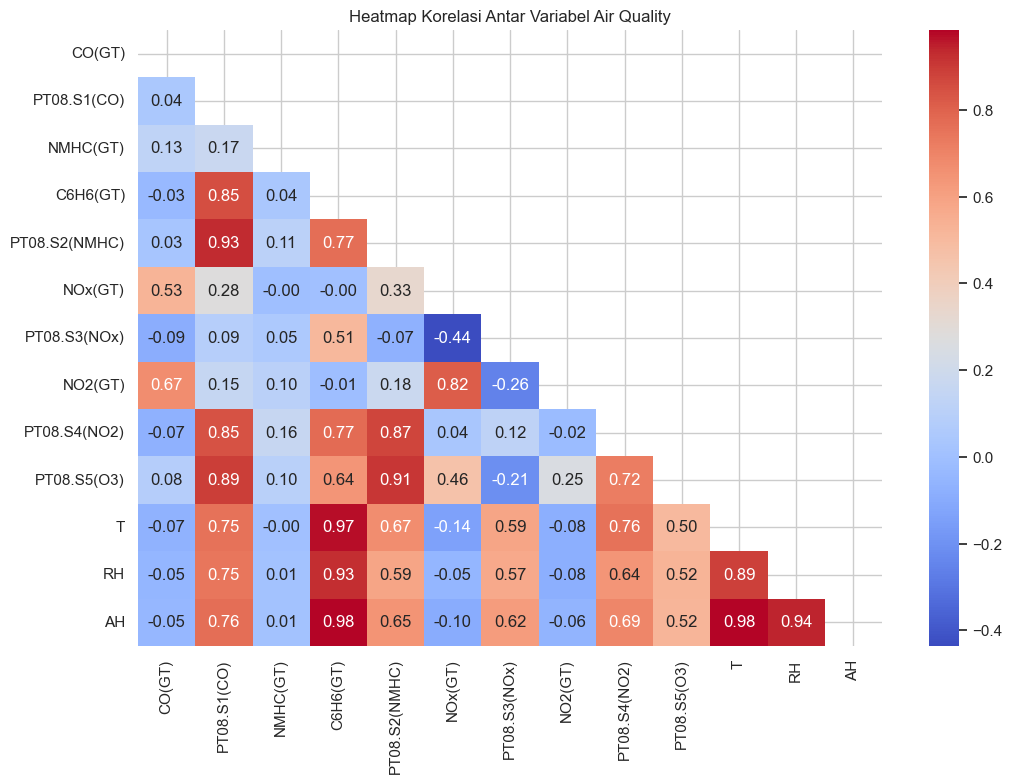

In [7]:
# Visualisasi 1: Matriks Korelasi
df_numeric = df.select_dtypes(include=[np.number])

corr = df_numeric.corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Variabel Air Quality')
plt.show()

**Analisis Heatmap:**
Heatmap korelasi menunjukkan bahwa konsentrasi CO(GT) memiliki hubungan positif yang cukup kuat dengan NO₂(GT) dan NOx(GT), yang mengindikasikan adanya keterkaitan antar gas polutan dari sumber yang sama. Beberapa sensor gas seperti PT08.S1, PT08.S2, dan PT08.S4 juga menunjukkan korelasi yang tinggi, menandakan peran penting sensor tersebut dalam mendeteksi pola polusi udara. Variabel lingkungan seperti suhu (T), kelembaban relatif (RH), dan kelembaban absolut (AH) saling berkorelasi kuat, namun memiliki pengaruh yang lebih rendah dibandingkan sensor gas. Hasil ini menunjukkan bahwa kombinasi sensor gas dan faktor lingkungan relevan untuk digunakan dalam pemodelan prediksi konsentrasi CO.

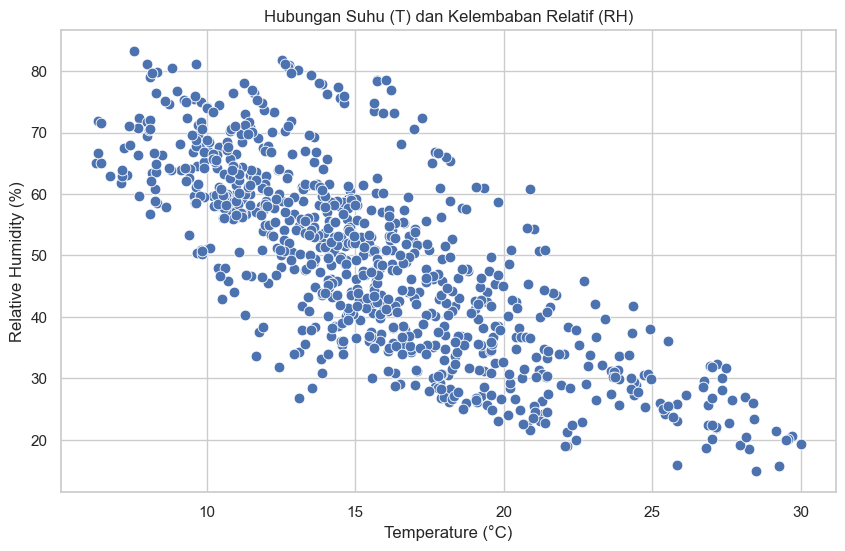

In [8]:
# Visualisasi 2: Hubungan Jam Belajar vs Jam Tidur berdasarkan Risiko
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='T',
    y='RH',
    s=60
)
plt.title('Hubungan Suhu (T) dan Kelembaban Relatif (RH)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


**AnalisisScatter Plot:**
Scatter plot menunjukkan adanya hubungan negatif antara suhu (T) dan kelembaban relatif (RH). Ketika suhu meningkat, kelembaban relatif cenderung menurun. Pola ini sesuai dengan karakteristik fisik udara dan menunjukkan bahwa faktor lingkungan memiliki keterkaitan yang jelas dalam kondisi kualitas udara.

### 5. Modeling & Training


Pada tahap ini dilakukan pembangunan dan pelatihan model machine learning
menggunakan algoritma Random Forest Regressor. Penjelasan pada tahap ini
meliputi algoritma yang digunakan, alasan pemilihan model, parameter penting,
serta proses training model.

1. **Algoritma yang Digunakan**  
   Algoritma yang digunakan adalah Random Forest Regressor, yaitu algoritma
   ensemble learning yang menggabungkan banyak decision tree. Setiap pohon
   keputusan menghasilkan prediksi yang kemudian dirata-ratakan untuk
   menghasilkan prediksi akhir yang lebih stabil dan akurat.

2. **Alasan Pemilihan Model**  
   Random Forest Regressor dipilih karena mampu menangani hubungan data yang
   bersifat non-linear, memiliki ketahanan terhadap overfitting, serta tidak
   sensitif terhadap perbedaan skala data. Selain itu, algoritma ini dikenal
   memiliki performa yang baik pada berbagai permasalahan regresi.

3. **Parameter Penting**  
   Beberapa parameter penting yang digunakan dalam pembuatan model antara lain
   jumlah pohon (n_estimators), kedalaman maksimum pohon (max_depth), jumlah
   minimum data untuk membagi node (min_samples_split), dan jumlah minimum data
   pada leaf node (min_samples_leaf). Parameter-parameter ini digunakan untuk
   mengontrol kompleksitas dan kinerja model.

4. **Proses Training Model**  
   Proses training dilakukan menggunakan data latih (training set). Model
   dilatih untuk mempelajari pola hubungan antara fitur input dan variabel
   target. Setelah proses training selesai, model siap digunakan untuk
   melakukan prediksi pada data uji dan dievaluasi menggunakan metrik evaluasi.


In [9]:
# Inisialisasi Mode
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

In [10]:
# Memilih fitur numerik
X_num = X.select_dtypes(include=[np.number])

In [11]:
# Evaluasi model dengan Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    rf_model,
    X_num,
    y,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

# Menghitung RMSE dari hasil cross-validation
rmse_scores = np.sqrt(-cv_scores)

print(f"Rata-rata RMSE CV: {rmse_scores.mean():.3f}")
print(f"Std RMSE CV      : {rmse_scores.std():.3f}")

Rata-rata RMSE CV: 0.287
Std RMSE CV      : 0.065


Hasil Time Series Cross-Validation menunjukkan RMSE rata-rata sebesar 0.287 dengan deviasi standar 0.065, yang menandakan performa model stabil.


In [12]:
# Ambil hanya kolom numerik
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

In [13]:
# Melatih model dan melakukan prediksi
rf_model.fit(X_train_num, y_train)
y_pred = rf_model.predict(X_test_num)

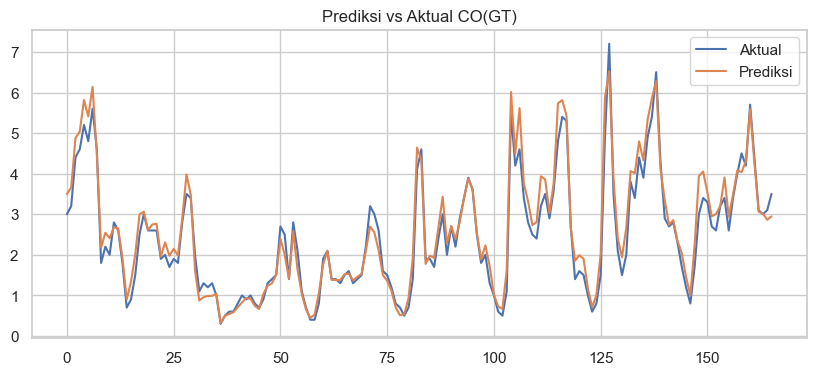

In [14]:
# Visualisasi perbandingan nilai aktual dan prediksi
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Aktual')
plt.plot(y_pred, label='Prediksi')
plt.legend()
plt.title('Prediksi vs Aktual CO(GT)')
plt.show()

**Analisis Prediksi vs Aktual CO(GT) pada Data Time Series:** Grafik menunjukkan bahwa pola prediksi model Random Forest Regressor mengikuti pola data aktual CO(GT) dengan cukup baik. Puncak dan lembah pada data aktual sebagian besar dapat ditangkap oleh model, yang menandakan bahwa model mampu mengenali pola temporal dalam data.

Meskipun terdapat beberapa perbedaan nilai pada titik tertentu, khususnya pada perubahan yang cukup tajam, secara umum hasil prediksi masih berada dekat dengan nilai aktual. Hal ini menunjukkan bahwa model memiliki performa yang stabil dan dapat digunakan untuk memprediksi konsentrasi CO(GT) pada data time series.


### 6. Evaluasi Model

Evaluasi model dilakukan untuk mengukur performa model machine learning dalam
memprediksi variabel target. Karena permasalahan yang diselesaikan merupakan
masalah regresi, maka metode evaluasi yang digunakan adalah MSE, MAE, dan R².

1. **Mean Squared Error (MSE)**  
   MSE mengukur rata-rata kuadrat selisih antara nilai aktual dan nilai
   prediksi. Metrik ini memberikan penalti yang lebih besar terhadap kesalahan
   prediksi yang besar, sehingga berguna untuk mendeteksi adanya kesalahan
   ekstrem pada hasil prediksi.

2. **Mean Absolute Error (MAE)**  
   MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai
   prediksi. Metrik ini mudah diinterpretasikan karena memiliki satuan yang
   sama dengan variabel target. Nilai MAE yang kecil menunjukkan bahwa model
   memiliki tingkat kesalahan prediksi yang rendah.

3. **R-Squared (R²)**  
   R² mengukur seberapa besar variasi data target yang dapat dijelaskan oleh
   model. Nilai R² berada pada rentang 0 hingga 1. Semakin mendekati nilai 1,
   semakin baik kemampuan model dalam menjelaskan pola data.

Berdasarkan hasil evaluasi yang diperoleh, nilai MSE dan MAE yang relatif kecil
menunjukkan bahwa model memiliki kesalahan prediksi yang rendah, sedangkan nilai
R² yang mendekati 1 menunjukkan bahwa model Random Forest Regressor mampu
memprediksi data dengan cukup baik dan memiliki kemampuan generalisasi yang baik.


In [15]:
# Evaluasi performa model regresi
print("Evaluasi Model Random Forest Regressor")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


Evaluasi Model Random Forest Regressor
MAE : 0.25869620526776693
RMSE: 0.3378884214220956
R2  : 0.9426277216492384


### Evaluasi Model Random Forest Regressor

Hasil evaluasi menunjukkan bahwa model Random Forest Regressor memiliki performa yang baik. Nilai **MAE sebesar 0.259** menunjukkan rata-rata kesalahan prediksi yang relatif kecil terhadap nilai aktual CO(GT). Nilai **RMSE sebesar 0.338** mengindikasikan bahwa kesalahan besar (outlier) tidak dominan dalam hasil prediksi model.

Selain itu, nilai **R² sebesar 0.943** menunjukkan bahwa model mampu menjelaskan sekitar **94% variasi data CO(GT)**. Dengan demikian, model yang dibangun sudah sesuai dan efektif untuk digunakan dalam memprediksi konsentrasi CO(GT).


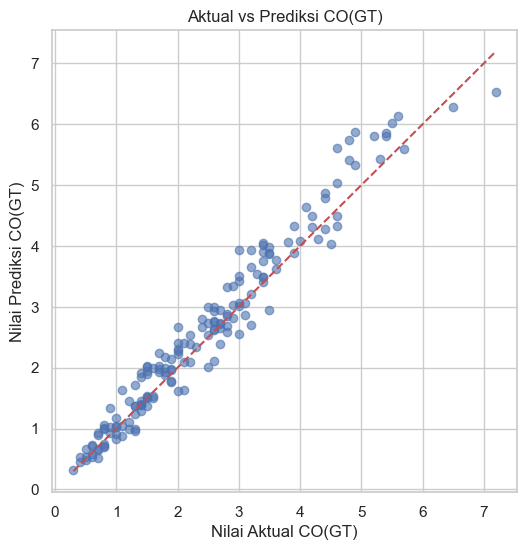

In [16]:
# Visualisasi hubungan nilai aktual dan prediksi
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel('Nilai Aktual CO(GT)')
plt.ylabel('Nilai Prediksi CO(GT)')
plt.title('Aktual vs Prediksi CO(GT)')
plt.show()


**Analisis Grafik Aktual vs Prediksi CO(GT):** Grafik menunjukkan bahwa sebagian besar titik prediksi berada di sekitar garis diagonal (y = x), yang menandakan bahwa nilai prediksi model mendekati nilai aktual. Hal ini menunjukkan bahwa model Random Forest Regressor mampu memprediksi konsentrasi CO(GT) dengan baik pada sebagian besar rentang data.

Penyebaran titik yang relatif kecil di sekitar garis diagonal mengindikasikan kesalahan prediksi yang rendah. Meskipun terdapat sedikit penyimpangan pada nilai CO(GT) yang lebih tinggi, pola umum masih mengikuti garis ideal, sehingga dapat disimpulkan bahwa model memiliki tingkat akurasi prediksi yang baik dan konsisten.


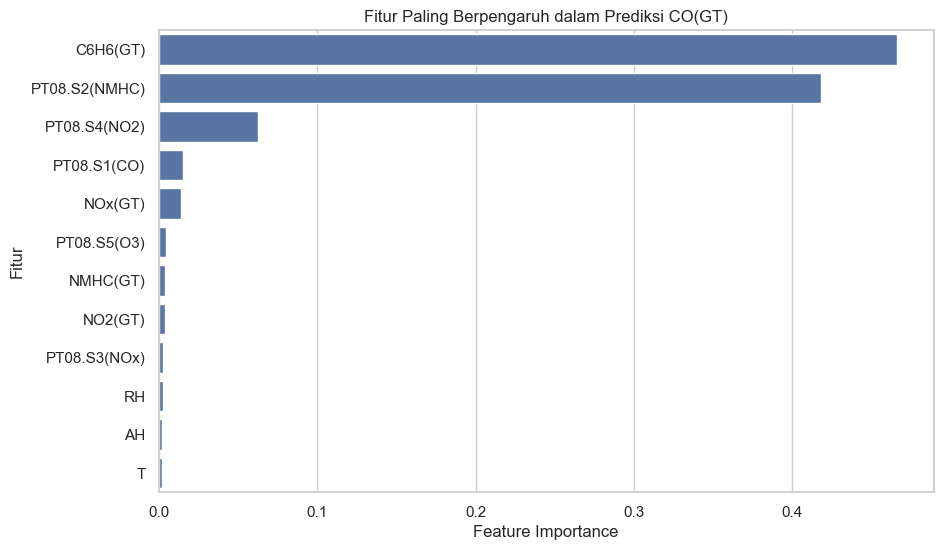

In [17]:
# Visualisasi Feature Importance Random Forest
importances = rf_model.feature_importances_

features = X_train_num.columns

feature_imp_df = (
    pd.DataFrame({
        'Fitur': features,
        'Kepentingan': importances
    })
    .sort_values(by='Kepentingan', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Kepentingan',
    y='Fitur',
    data=feature_imp_df
)
plt.title('Fitur Paling Berpengaruh dalam Prediksi CO(GT)')
plt.xlabel('Feature Importance')
plt.ylabel('Fitur')
plt.show()


**Analisis Feature Importance:** Berdasarkan grafik feature importance, fitur **C6H6(GT)** memiliki pengaruh paling besar dalam prediksi konsentrasi CO(GT), diikuti oleh **PT08.S2(NMHC)**. Hal ini menunjukkan bahwa konsentrasi benzena dan sinyal sensor NMHC merupakan faktor utama yang berkontribusi terhadap prediksi CO(GT) pada model Random Forest Regressor.

Sementara itu, fitur lain seperti **PT08.S4(NO2)** dan **PT08.S1(CO)** memiliki kontribusi yang lebih kecil, sedangkan variabel lingkungan seperti suhu (T), kelembapan relatif (RH), dan kelembapan absolut (AH) memberikan pengaruh yang sangat terbatas. Hasil ini menunjukkan bahwa model lebih banyak mengandalkan variabel terkait gas dibandingkan faktor lingkungan dalam memprediksi CO(GT).


Evaluasi model dilakukan untuk mengetahui performa model Random Forest Regressor dalam melakukan prediksi. 
Pada tahap ini digunakan beberapa metrik evaluasi regresi untuk mengukur tingkat kesalahan prediksi model.

Metrik evaluasi yang digunakan meliputi:
- Mean Absolute Error (MAE), yang mengukur rata-rata kesalahan absolut antara nilai aktual dan nilai prediksi.
- Root Mean Squared Error (RMSE), yang memberikan penalti lebih besar terhadap kesalahan prediksi yang besar.
- R-Squared (R²), yang mengukur kemampuan model dalam menjelaskan variasi data target.

Nilai MAE dan RMSE yang relatif kecil menunjukkan bahwa model memiliki tingkat kesalahan prediksi yang rendah,
sedangkan nilai R² yang mendekati 1 menunjukkan bahwa model mampu menjelaskan sebagian besar variasi data target.

Berdasarkan hasil evaluasi tersebut, dapat disimpulkan bahwa model Random Forest Regressor memiliki performa
yang baik dan sesuai untuk digunakan dalam memprediksi data uji.


### 7. Kesimpulan & Rekomendasi

Berdasarkan hasil pengolahan dan analisis dataset AirQualityUCI, dapat ditarik
beberapa kesimpulan sebagai berikut:

1. **Keberhasilan Model**  
   Model Random Forest Regressor berhasil digunakan untuk memprediksi variabel
   target kualitas udara yang bersifat numerik dan kontinu. Hal ini terlihat
   dari hasil evaluasi model menggunakan MAE, MSE, dan R², yang menunjukkan
   bahwa model mampu mempelajari pola hubungan antara data sensor gas, kondisi
   lingkungan (temperatur, kelembaban), dan konsentrasi polutan udara dengan
   cukup baik.

2. **Kelebihan dan Keterbatasan Model**  
   Kelebihan model Random Forest Regressor pada dataset AirQualityUCI adalah
   kemampuannya dalam menangani hubungan data yang kompleks dan tidak linear
   antara sensor elektronik dan konsentrasi gas polutan. Model juga relatif
   stabil terhadap noise yang umum terdapat pada data sensor kualitas udara.  
   Namun, keterbatasan model ini adalah kebutuhan komputasi yang cukup besar
   serta tingkat interpretabilitas yang rendah, sehingga sulit untuk
   menjelaskan secara detail kontribusi masing-masing sensor terhadap hasil
   prediksi.

3. **Potensi Pengembangan Selanjutnya**  
   Pengembangan selanjutnya dapat dilakukan dengan melakukan tuning
   hyperparameter untuk meningkatkan akurasi model, memilih fitur sensor yang
   paling berpengaruh terhadap target, serta mencoba pendekatan time series
   mengingat data AirQualityUCI bersifat data waktu (hourly data). Selain itu,
   penggunaan model lain sebagai pembanding dapat membantu memperoleh performa
   prediksi yang lebih optimal.

Secara keseluruhan, model yang dibangun sudah cukup efektif dalam memanfaatkan
data sensor dan variabel lingkungan pada dataset AirQualityUCI untuk melakukan
prediksi kualitas udara

### 8. Dokumentasi Laporan Proyek
Bagian ini berisi dokumentasi dari seluruh proses pengerjaan proyek machine
learning yang telah dilakukan menggunakan dataset AirQualityUCI. Dokumentasi
disusun secara terstruktur di dalam Jupyter Notebook untuk memastikan setiap
tahapan dapat dipahami dengan jelas.

Dokumentasi proyek meliputi:
- Penjelasan tujuan proyek dan deskripsi dataset yang digunakan
- Proses preprocessing data untuk menyiapkan data sebelum pemodelan
- Exploratory Data Analysis (EDA) untuk memahami karakteristik dan pola data
- Pembuatan dan training model Random Forest Regressor
- Evaluasi performa model menggunakan metrik regresi yang sesuai
- Kesimpulan dan insight dari hasil pemodelan

Seluruh kode, visualisasi, dan penjelasan disajikan dalam satu notebook agar
mudah direproduksi dan dipahami. Dengan adanya dokumentasi ini, proyek dapat
digunakan sebagai referensi untuk pengembangan lebih lanjut maupun evaluasi
kinerja model di masa mendatang.